In [198]:
# import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# algos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [199]:
# data loading and overview
original_data = pd.read_csv("../data/telecome.csv")
df  = original_data.copy()

In [200]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [202]:
# enlist cat and num columns
categorical_cols = df.select_dtypes(include="object").columns
numerical_cols = df.select_dtypes(exclude="object").columns

print(f"Categorical cols: {categorical_cols}")
print("-"*80)
print(f"Numerical cols: {numerical_cols}")

Categorical cols: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')
--------------------------------------------------------------------------------
Numerical cols: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [203]:
# get the missing values

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [204]:
df.duplicated().sum()

np.int64(0)

In [205]:
# type conversion for totalcharges col

df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [206]:
# drop the cols that lack the total charges

df = df[df['TotalCharges'].str.strip() != '']

In [207]:
df[df['TotalCharges']==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [208]:
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [209]:
df['TotalCharges'].dtype

dtype('float64')

In [210]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [211]:
# since we do not need the column: customerID, we should drop it
# df.drop(columns=['customerID'], inplace=True)    # this will be automatically dropped in the pipeline later

In [212]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                        'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                        'PaymentMethod']

In [213]:
# separate independent and dependent features

X = df[numeric_features + categorical_features]
y = df[target_feature]

In [214]:
# check whether data is balanced or not
y.value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

##### It seems that data is not balanced since there is not 50-50 split for the target

In [215]:
# split the train and test dataset
X_train, X_test, y_train,  y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [216]:
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

In [217]:
y_train

4499    1
1933    0
4668    0
5681    0
3610    1
       ..
5161    0
3451    0
4135    0
4249    0
272     1
Name: Churn, Length: 4922, dtype: int64

In [218]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
# Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical Preprocessing Batch

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# Combine both batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)

    ],
    remainder='drop'
)

# Create the final, full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,

    ))
])

In [219]:
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [220]:
y_pred = clf_pipeline.predict(X_test)

In [221]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
y_proba

array([0.39717109, 0.57209269, 0.12870455, ..., 0.74641361, 0.03938791,
       0.76153802])

#### Evaluation of the model

In [222]:
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, classification_report

In [223]:
# model evaluation

print(f"Precision score: {precision_score(y_test, y_pred)}")
print(f"Recall value: f{recall_score(y_test, y_pred)}")
print(f"Confusion matrix: {confusion_matrix(y_test, y_pred)}")
print(f"F1 score: {f1_score(y_test, y_pred)}")

Precision score: 0.503954802259887
Recall value: f0.7950089126559715
Confusion matrix: [[1110  439]
 [ 115  446]]
F1 score: 0.6168741355463347


In [224]:
# classification report 
from sklearn.metrics import classification_report
print(f"Classification report: {classification_report(y_test, y_pred)}")

Classification report:               precision    recall  f1-score   support

           0       0.91      0.72      0.80      1549
           1       0.50      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.75      2110



##### ROC_AUC

In [225]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8377764275497158


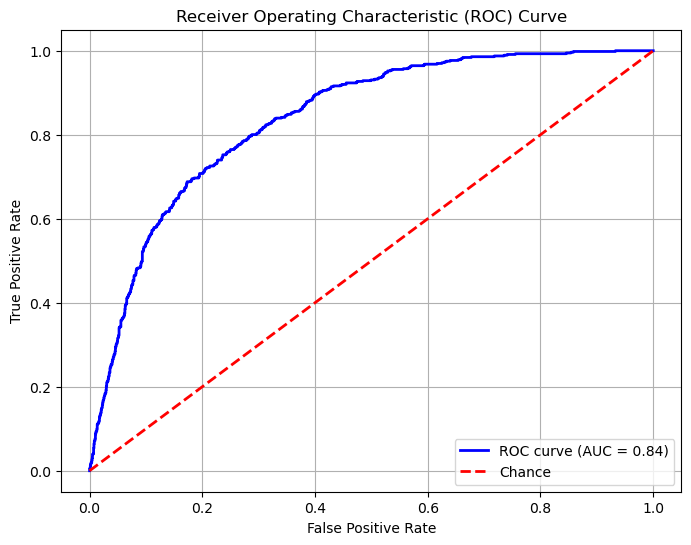

In [226]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [227]:
# using random forest algo

rf_pipeline = Pipeline(steps=[
		('preprocessor', preprocessor),
		('model', RandomForestClassifier(
				class_weight='balanced',
				random_state=42,
				n_estimators=100
		))
])

In [228]:
# fit the model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [229]:
# predict and also find the probability
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [230]:
# get the classification report
print(f"Classification report: {classification_report(y_test, y_pred_rf)}")

Classification report:               precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.62      0.47      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.70      2110
weighted avg       0.77      0.78      0.77      2110



In [231]:
# cross validation  
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(clf_pipeline, 
                            X_train, 
                            y_train, 
                            scoring='roc_auc',
                            cv=5)
print(f"Cross-validation AUC scores: {cv_scores.mean()}")

Cross-validation AUC scores: 0.8481889965677436


In [232]:
# cross validation for random forest model
cv_auc = cross_val_score(rf_pipeline,
                        X_train,
                        y_train,
                        scoring='roc_auc',
                        cv=5)
print("Random Forest CV AUC: ", cv_auc.mean())

Random Forest CV AUC:  0.8232642187346351


In [233]:
from sklearn.model_selection import GridSearchCV

param_grid = {
	'model__n_estimators': [200, 400],
 	'model__max_depth': [None, 10, 20],
  'model__min_samples_split': [2,10],
  'model__min_samples_leaf': [1,5]
}

In [234]:
# grid for random forest
grid_search_rf = GridSearchCV(
  estimator=rf_pipeline, 
  param_grid=param_grid, 
  cv=3, 
  scoring='roc_auc',
  n_jobs= 1,
  verbose=2
  )
grid_search_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=400; total time=   1.5s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=400; total time=   1.5s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=400; total time=   1.5s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=10, model__n_estimators=200; total time=   0.7s
[CV] END model__max_d

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'tenure']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='i...
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 5],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [200, 400]},
             scoring='roc_auc', verbose=2)

In [235]:
# get the best params
print("Best parameters found: ", grid_search_rf.best_params_)

# get the best score
print("Best AUC score: ", grid_search_rf.best_score_)

Best parameters found:  {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best AUC score:  0.8462454589636897


In [236]:
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:,1]

In [237]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_best_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)


In [240]:
from sklearn.metrics import accuracy_score, classification_report
print(roc_auc_rf)
print(accuracy_score(y_test,y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.7587731260119518
0.7815165876777251
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1549
           1       0.62      0.47      0.53       561

    accuracy                           0.78      2110
   macro avg       0.72      0.68      0.70      2110
weighted avg       0.77      0.78      0.77      2110



In [243]:
# get the features names
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

In [244]:
feat_imp = pd.DataFrame({
	'feature': feature_names,
 'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
2,num__tenure,0.131333
37,cat__Contract_Month-to-month,0.121669
1,num__TotalCharges,0.100410
39,cat__Contract_Two year,0.068434
0,num__MonthlyCharges,0.068366
19,cat__OnlineSecurity_No,0.050562
28,cat__TechSupport_No,0.050227
17,cat__InternetService_Fiber optic,0.044391
44,cat__PaymentMethod_Electronic check,0.034472
22,cat__OnlineBackup_No,0.019557


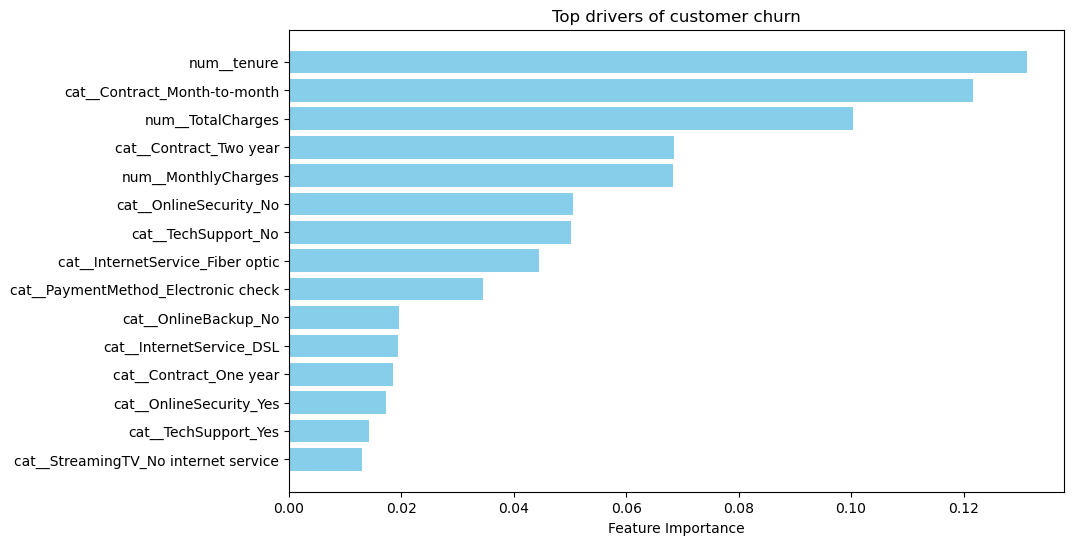

In [248]:
# plot the bar graph
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Top drivers of customer churn')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important
plt.show()

In [249]:
# find the optimum threshold for probability of classification
thresholds = np.arange(0.1, 0.9, 0.05)
results = []
for t in thresholds:
  y_pred_threshold = (y_proba_best_rf >= t).astype(int)
  precision = precision_score(y_test, y_pred_threshold)
  recall = recall_score(y_test, y_pred_threshold)
  f1 = f1_score(y_test, y_pred_threshold)
  results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])
print(results_df)

    threshold  precision    recall        f1
0        0.10   0.344828  0.980392  0.510204
1        0.15   0.366035  0.964349  0.530652
2        0.20   0.393284  0.939394  0.554445
3        0.25   0.413408  0.923351  0.571114
4        0.30   0.437828  0.891266  0.587199
5        0.35   0.461977  0.866310  0.602604
6        0.40   0.486097  0.841355  0.616188
7        0.45   0.511918  0.803922  0.625520
8        0.50   0.539846  0.748663  0.627334
9        0.55   0.569094  0.682709  0.620746
10       0.60   0.598639  0.627451  0.612707
11       0.65   0.628283  0.554367  0.589015
12       0.70   0.644068  0.474153  0.546201
13       0.75   0.680982  0.395722  0.500564
14       0.80   0.710526  0.288770  0.410646
15       0.85   0.773723  0.188948  0.303725


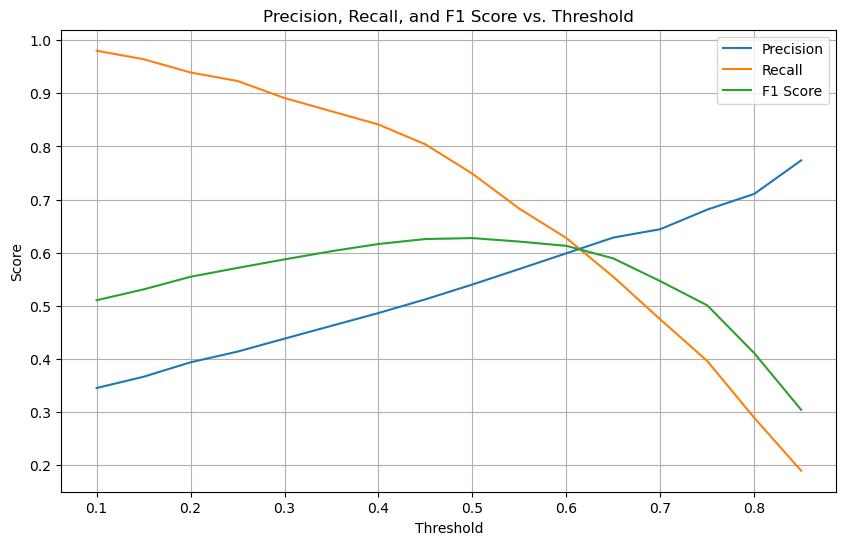

In [250]:
# plot precision, recall tradeoff by threshold
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['precision'], label='Precision')
plt.plot(results_df['threshold'], results_df['recall'], label='Recall')
plt.plot(results_df['threshold'], results_df['f1'], label='F1 Score')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()


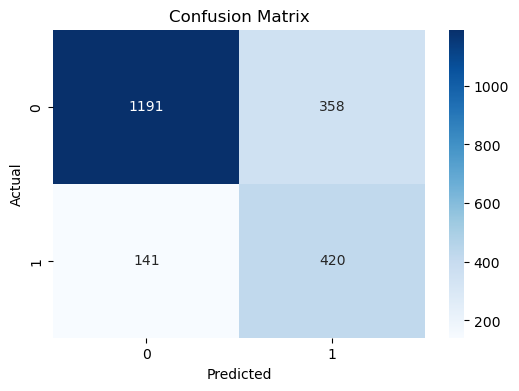

In [251]:
# confusion matrix
y_pred_final = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
import seaborn as sns 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


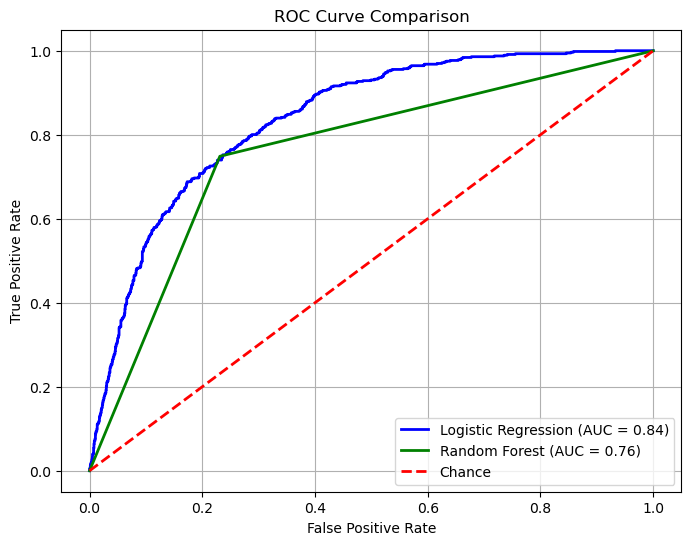

In [254]:
# compare roc_auc curve for logistic regression and random forest


roc_auc_lr = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label
=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label
=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw
=2, linestyle='--', label='Chance')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()	

In [256]:
churn_prob = y_proba_rf

risk_df = pd.DataFrame({
	"churn_probability": churn_prob
})


# changing continuous numerical values into categorical bins
risk_df['risk_level'] = pd.cut(
	risk_df['churn_probability'],
	bins = [0, 0.3, 0.6, 1],
	labels= ['Low Risk', 'Medium Risk', 'High Risk']
)
risk_df['risk_level'].value_counts()

risk_level
Low Risk       1111
Medium Risk     467
High Risk       305
Name: count, dtype: int64

In [257]:
risk_df

,churn_probability,risk_level
0,0.117343,Low Risk
1,0.260000,Low Risk
2,0.020000,Low Risk
3,0.170000,Low Risk
4,0.010000,Low Risk
...,...,...
2105,0.180000,Low Risk
2106,0.000000,NaN
2107,0.280000,Low Risk
2108,0.000000,NaN
